<font color="Teal" face="Comic Sans MS,arial">
  <h1 align="center"><i>EDA - Clasificador de Enfermedades Dermatologicas Caninas</i></h1>
  </font>
  <font color="Black" face="Comic Sans MS,arial">
  <h5 align="center"><i>Profesor: José Eduardo Rodríguez Barrios</i></h5>
  <h5 align="center"><i>Ayudante: Carlos Cuauhtémoc Gutiérrez Salazar	</i></h5>
  <h5 align="center"><i>Materia:Proyecto 1 </i></h5>
   <h5 align="center"><i>Alumno : García Trejo Ricardo Fabián</i></h5>
  <h5 align="center"><i>No.Cuenta: 318290953</i></h5>

# **Objetivo**

El objetivo de este proyecto es desarrollar un clasificador de imágenes basado en redes

neuronales convolucionales (CNN) o Vision Transformers capaz de clasificar enfermedades dermatologicas  en perros.

El clasificador parte del supuesto que el perro posee una enfermedad y  deberá ser capaz de identificar y clasificar el tipo de enfermedad presentada .

Para poder dar mejor precision al modelo utilizaremos la metrica $F_{1}-Score$ de la cual esperamos obtener una precision $F_{1} > 90 \% $ en
el conjunto de validación, lo que permitirá apoyar a la población en el adecuado cuidado
de la salud de sus mascotas. Asimismo, se pretende contribuir al desarrollo de soluciones
tecnol ́ogicas en el  ́ambito de la medicina veterinaria.

# **Revisión del Data-set**

Tomaremos como punto de partida el data- set  "Dog skin disease Computer Vision Dataset" obtenido de Roboflob el cual operaremos mediante Pythorch para su manipulacion

In [ ]:
#descomprimimos el data-set el cual fue comprimido para tener una mejor manipulacion
!unzip "/content/Dog_Skin_Diseases_mio_v2.zip" -d "/content/disease"

Archive:  /content/Dog_Skin_Diseases_mio_v2.zip
   creating: /content/disease/test/
   creating: /content/disease/test/Bacterial_dermatosis/
  inflating: /content/disease/test/Bacterial_dermatosis/1000010516_x16_jpg.rf.bae3a88cf9d9240fad7046b65de2f235.jpg  
  inflating: /content/disease/test/Bacterial_dermatosis/1000010543_x16_jpg.rf.3d5c8fbd838ce372995e687752cdb307.jpg  
  inflating: /content/disease/test/Bacterial_dermatosis/1000010586_x4_jpg.rf.e950b7016d652bfd6bb59b0571a8a5ac.jpg  
  inflating: /content/disease/test/Bacterial_dermatosis/1000010597_x4_jpg.rf.e9ccc64314fe4b9fcb186f4d04167b9a.jpg  
  inflating: /content/disease/test/Bacterial_dermatosis/fly_strike_dermatitis_in_dogs_4935_6_600_jpg.rf.2b5cdf6cbc9b09d0dd7b67c66c2fc437.jpg  
  inflating: /content/disease/test/Bacterial_dermatosis/hot-spot-dog-paw-sh_1862261590_jpg.rf.e3dc26d0a6ee239b4917bcf24f0d3b12.jpg  
  inflating: /content/disease/test/Bacterial_dermatosis/red-circle-ri-1mo-450_jpg.rf.14141cbb655f1403ada014db2786585d

In [ ]:
#importar librerias
import torch
from torchvision import datasets, transforms
from torch.utils.data import dataset, DataLoader as dataloader
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil
from pathlib import Path
import torchvision.transforms as transforms
from torchvision.transforms import ToPILImage

Ahora obtendremos los accesos necesarios para contabilizar las imagenes del data-set

In [ ]:
#directorio principal de las imagenes
DATA_DIR = Path("/content/disease")
# redimncion de las imagenes
IMAGE_SIZE = (256,256)
#Tamaño del batch
BATCH_SIZE = 32
#Trasnformar a item de pythorch
transform = transforms.Compose([
    #transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std= [0.5,0.5,0.5])
])

# Datasets y DataLoaders del data-set
train_plain = datasets.ImageFolder(DATA_DIR / 'train', transform=transform)
val_dataset = datasets.ImageFolder(DATA_DIR / 'valid', transform=transform)
test_dataset = datasets.ImageFolder(DATA_DIR / 'test', transform=transform)

train_plain_loader = dataloader(
    train_plain,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
val_loader = dataloader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,

)
test_loader = dataloader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,

)

print('Clases:', train_plain.classes)
print('Imagenes de Entrenamineto:', len(train_plain), '| Imagenes de Validacion:', len(val_dataset), '| Imagenes de Prueba:', len(test_dataset))
print('Categorias',train_plain.class_to_idx)


Clases: ['Bacterial_dermatosis', 'Fungal_infections', 'Healthy', 'Hot Spots', 'Hypersensitivity']
Imagened de Entrenamineto: 261 | Imagenes de Validacion: 80 | Imagenes de Prueba: 37
Categorias {'Bacterial_dermatosis': 0, 'Fungal_infections': 1, 'Healthy': 2, 'Hot Spots': 3, 'Hypersensitivity': 4}


Podemos observar que el dataset se divide en 10 categorias


Contando con


Ahora veamos como se distribuyen en estas categorias

In [ ]:
#sabemos que se tienen 11 clases
def Conteo(data):
  C = np.zeros(5)
  E = []
  for j in range(5):
    A=0
    for i in data.samples:
      if i[1] == j:
        A += 1
    C[j]=A
    E.append(data.classes[j])
  return C,E

#se obtiene el conteo de imagenes por clase en cada grupo (train,val,test)
Im_Entrenamiento , Clases_Entrenamiento = Conteo(train_plain)
Im_Prueba , Clases_Prueba = Conteo(test_dataset)
Im_Validacion , Clases_Validacion = Conteo(val_dataset)

#nos proporciona el total de imagenes por categoria
if Clases_Entrenamiento == Clases_Prueba == Clases_Validacion:
  Total = Im_Entrenamiento + Im_Prueba + Im_Validacion
print(Total)
print(Clases_Entrenamiento)

[77. 81. 71. 72. 77.]
['Bacterial_dermatosis', 'Fungal_infections', 'Healthy', 'Hot Spots', 'Hypersensitivity']


Podemos visualizar la distribucion de las imagenes en la siguiente grafica

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Bacterial_dermatosis'),
  Text(1, 0, 'Fungal_infections'),
  Text(2, 0, 'Healthy'),
  Text(3, 0, 'Hot Spots'),
  Text(4, 0, 'Hypersensitivity')])

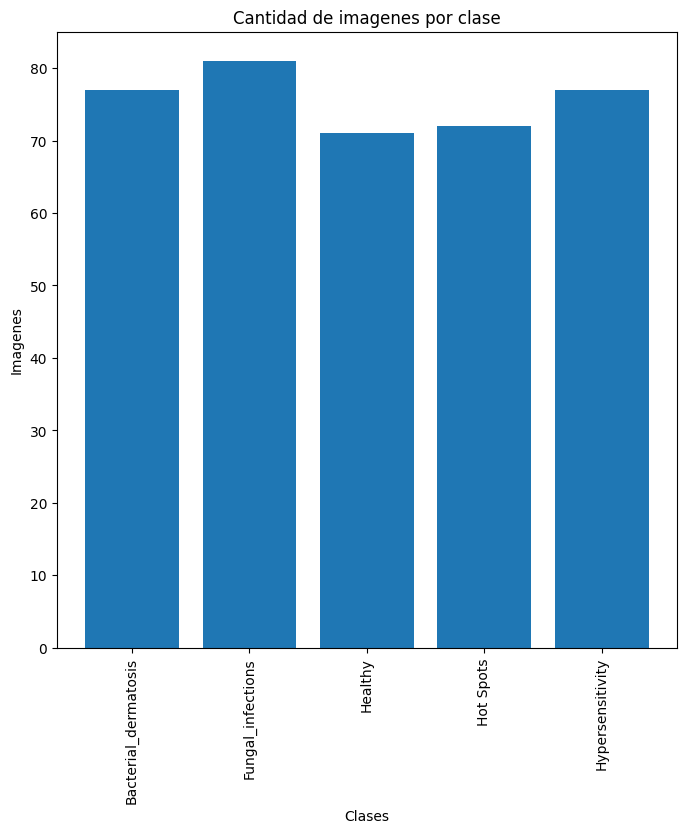

In [ ]:
#Grafica General
plt.figure(figsize=(8,8))
plt.bar(Clases_Entrenamiento,Total)
plt.title('Cantidad de imagenes por clase')
plt.xlabel('Clases')
plt.ylabel('Imagenes')
plt.xticks(rotation=90)

Tambien podemos ver como se distribuyen entre los subconjuntos de Train , Validation , Test

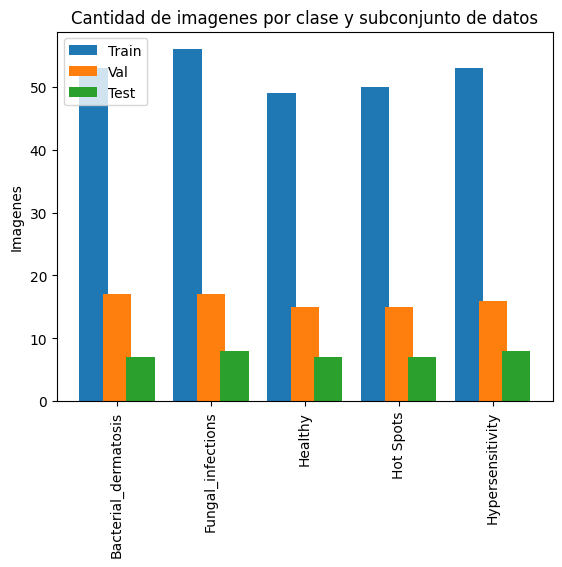

In [ ]:
#Grafica de barras
co = np.arange(len(Clases_Entrenamiento))
an = 0.3
fig, ax = plt.subplots()
ax.bar(co-0.25,Im_Entrenamiento,an,label='Train')
ax.bar(co,Im_Validacion,an,label='Val')
ax.bar(co+0.25,Im_Prueba,an,label='Test')
ax.set_title('Cantidad de imagenes por clase y subconjunto de datos')
ax.set_ylabel('Imagenes')
ax.set_xticks(co)
ax.set_xticklabels(Clases_Entrenamiento,rotation=90)
plt.legend(loc = 'upper left')
plt.show()

Podemos ver que se encuentra en exceso desbalanceado  ya que las categorias como "Dermatitis" , "Healthy" , "Demodicosis" , "Ringworm" poseen el mayor numero de imagenes

Esto nos da 2 posibilidades para el futuro
* Podemos equipara dichas clases con las demas y posteriormente hacer data-augmentation

* complementar las demas categorias con diversos data-sets para emparejar las clases

## Visualización de Imágenes

A continuacion Mostraremos grupos de $3 \ x \ 3$ imagenes de cada cateroria,

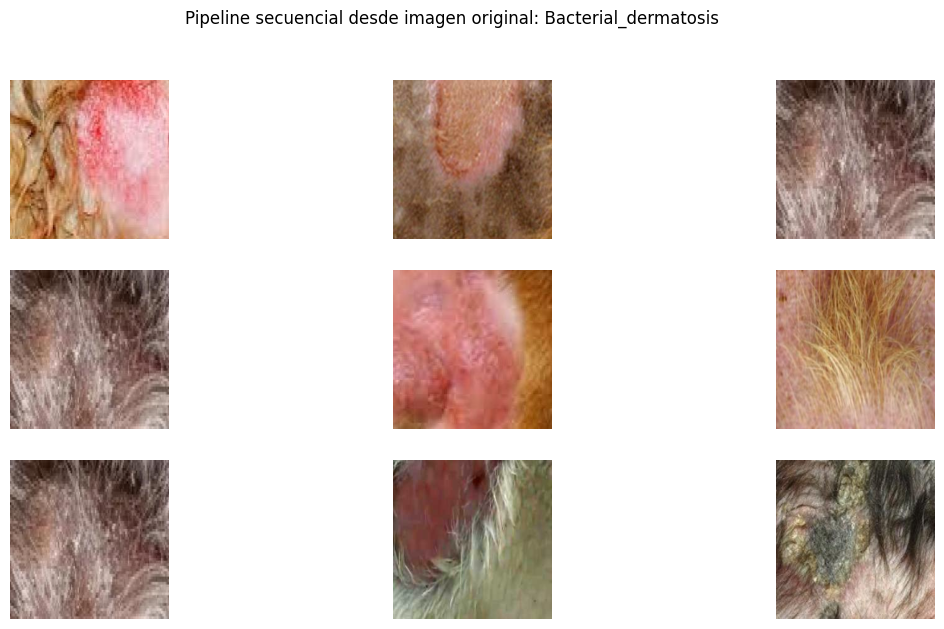

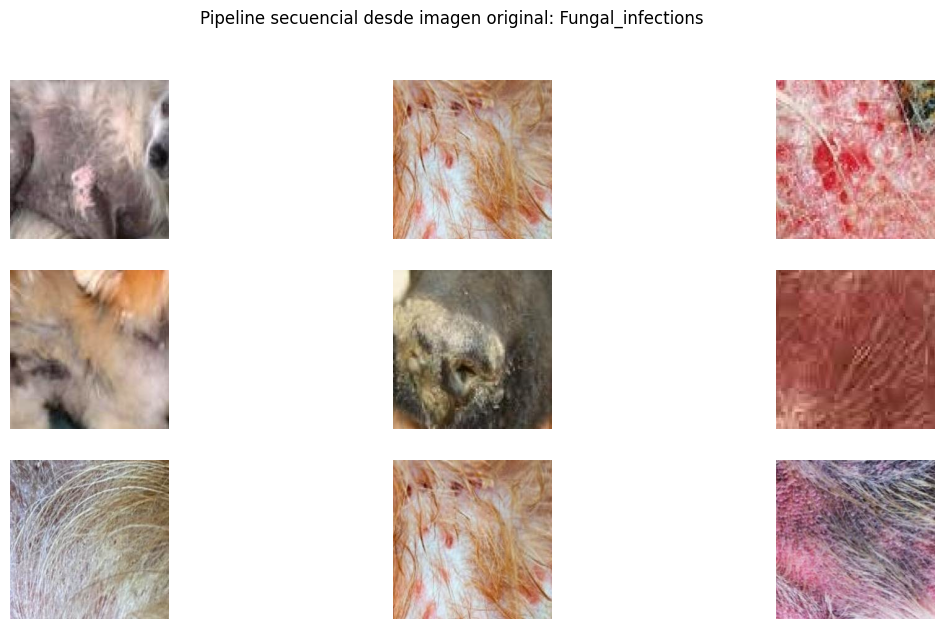

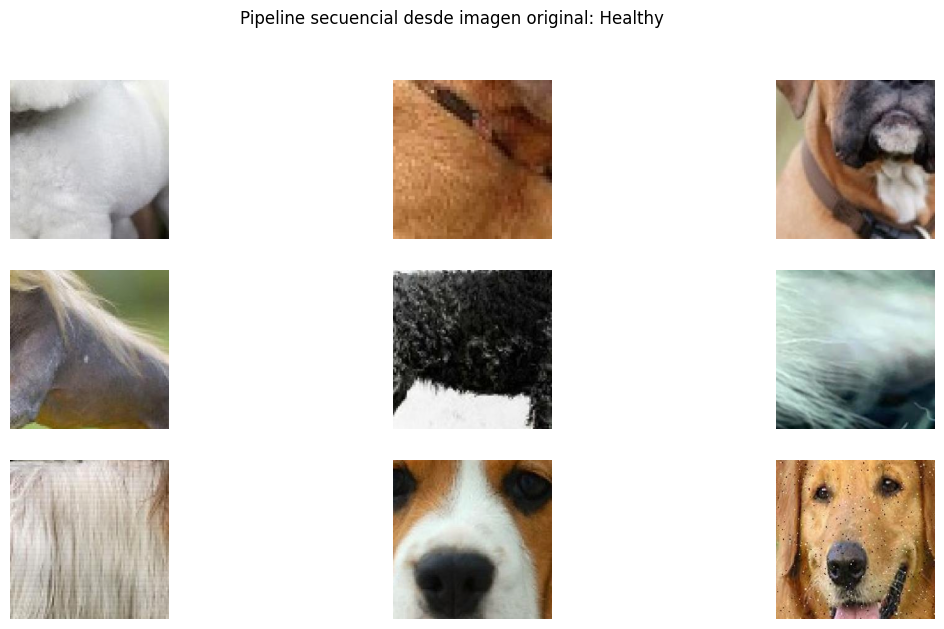

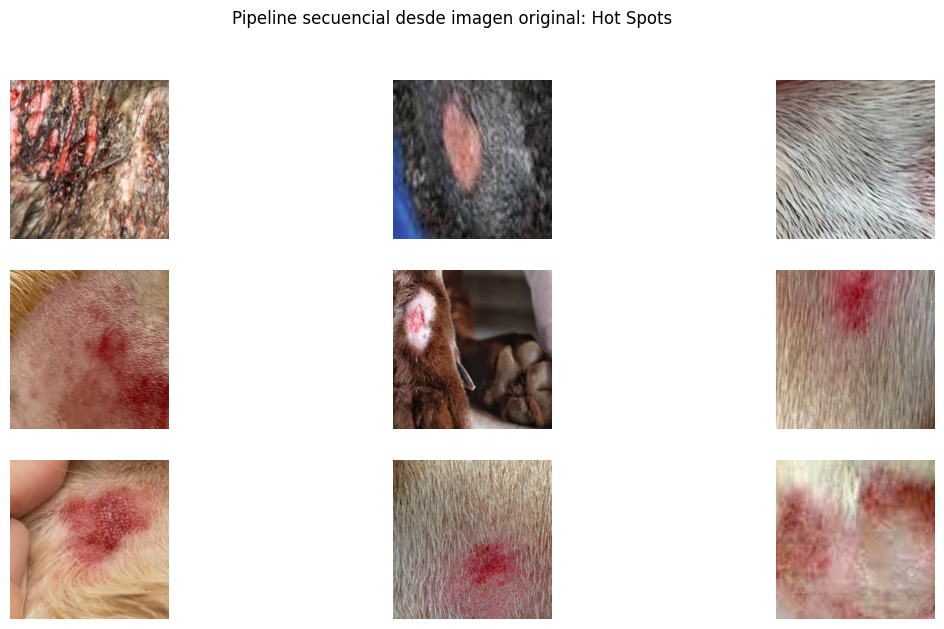

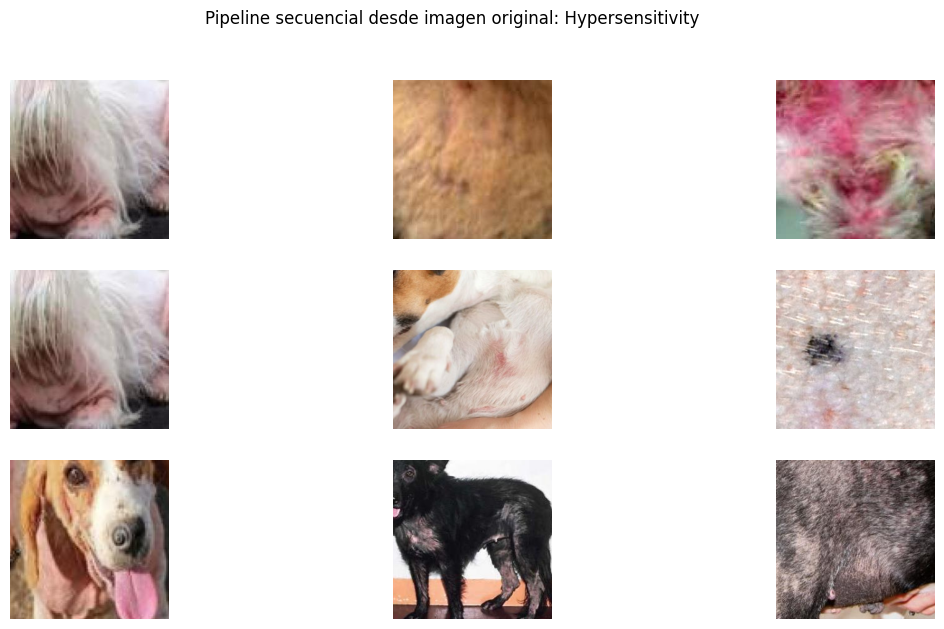

In [ ]:
#se mostraran algunas imagenes del subconjunto Train
classes1 = train_plain_loader.dataset.classes
#F =[0,67,655,1199,1253,1682,2258,2325,2518,2879,2922,3500]
# dataset de roboflow
#F = [0,67,611,1040,1616,1809,1870,2458,2512,2579,2622,3520]
#Dataset kaggle
#F = [0,588,1134,1509,2001,2231,3022]
#Dataset propio
F = [0,53,109,158,208,261]
for k in range(len(classes1)):
  fig, axes = plt.subplots(3, 3, figsize=(14, 7))

  for i in range(3):
    for j in range(3):
      num = np.random.randint(F[k],F[k+1])
      ida = train_plain_loader.dataset[num][0]
      ida = (ida - ida.min()) / (ida.max() -ida.min() )
      axes[i,j].imshow(np.transpose(ida,(1,2,0)))
      axes[i,j].axis('off')
  plt.suptitle(f'Pipeline secuencial desde imagen original: {classes1[k]} ')

Podemos notar que Todas las imagenes del Data-set se poseen el mismo tamaño siendo este (640,640), ademas es bastante variada la toma de la foto, hay desde imagenes que solo muestran la enfermedad en cuestion y otras son fotos de del perro completo con la enfermedad visible.

Dando un vistazo al conjunto de imagenes es posible realizar segmentaciones de las misma sin perder informacion muy relevante, para evitar que la red aprenda los fondos y siluetas del perro (aunque estas sean pocas)

La dimension de las imagenes podemos verla con el siguiente ejemplo

In [ ]:
#Tomamos las imagenes de entrenamiento
dataset1 = datasets.ImageFolder(root= DATA_DIR / 'train' , transform= transform)
#elegimos una de ellas
img , lbl = dataset1[5]

print(f"tamaño: {img.shape}")
print(f"rango: {img.min()} - {img.max()}")
print(f"categoria: {lbl}")

tamaño: torch.Size([3, 256, 256])
rango: -1.0 - 0.9686274528503418
categoria: 0


Otro problema al que nos enfrentamos es el del duplicado de las imagenes , Al visualizar todas las imagenes del data-set, podemos encontrar copias de algunas imagenes con alguna modificacion de rotación.

Para poder equilibrar el tamaño de las clases podemos prescindir de ellas

Text(0.5, 0.98, 'Pipeline secuencial desde imagen original: Hot Spots ')

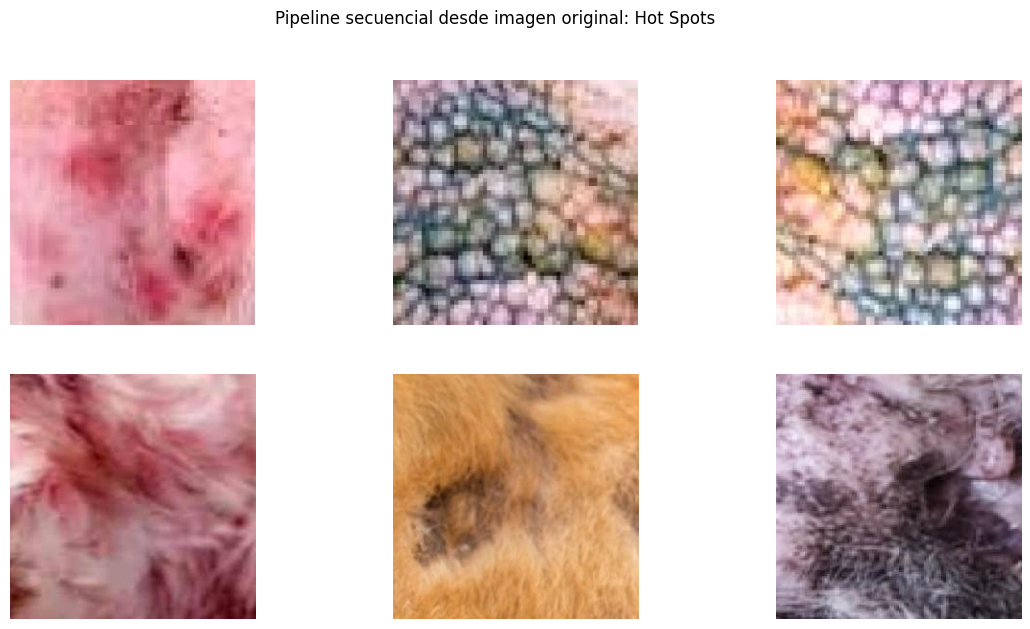

In [ ]:
fig, axes = plt.subplots(2,3, figsize=(14, 7))
A = 0
for i in range(2):
    for j in range(3):
      #num = np.random.randint(F[k],F[k+1])
      ida = train_plain_loader.dataset[(80+A)][0]
      ida = (ida - ida.min()) / (ida.max() -ida.min() )
      axes[i,j].imshow(np.transpose(ida,(1,2,0)))
      axes[i,j].axis('off')
      A += 1
plt.suptitle(f'Pipeline secuencial desde imagen original: {classes1[3]} ')